# TITANIC SURVIVAL


In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('C:\\Users\\Renitia\\OneDrive\\Desktop\\Porto\\Portfolio\\data\\Titanic_train.csv')

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## About Dataset

 The Titanic_train.csv file includes a target column called Survived
 
 a passenger survived (1) 
 
 did not survive (0)

In [38]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


 The Titanic_train.csv file includes detailed information for 891 passengers 

 missing file on column age and cabin

In [39]:
df["cabin_missing"] = df["Cabin"].isnull()

pd.crosstab(df["Pclass"], df["cabin_missing"], normalize="index") * 100

cabin_missing,False,True
Pclass,,
1,81.481481,18.518519
2,8.695652,91.304348
3,2.443992,97.556008


Missing cabin values are disproportionately concentrated among third-class passengers, suggesting that the missingness is related to passenger class rather than occurring completely at random.

In [40]:
df["Cabin_missing"] = df["Cabin"].isnull()

pd.crosstab(
    df["Survived"], 
    df["cabin_missing"], 
    normalize="index") * 100

cabin_missing,False,True
Survived,,
0,12.386157,87.613843
1,39.766082,60.233918


In [41]:
pd.crosstab(df["cabin_missing"],df["Survived"],  normalize="index") * 100

Survived,0,1
cabin_missing,,
False,33.333333,66.666667
True,70.014556,29.985444


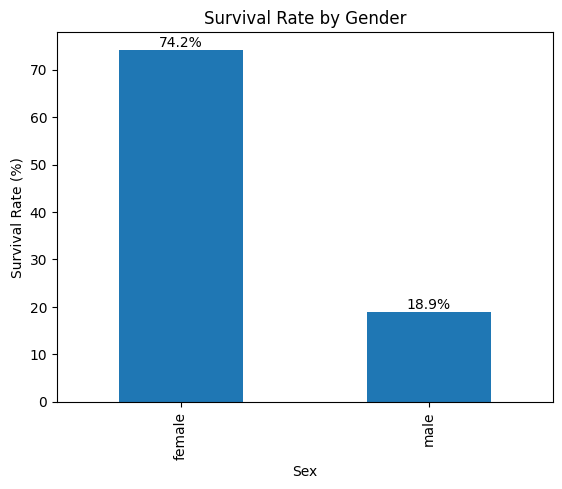

In [42]:
survival_by_gender = (
    df.groupby("Sex")["Survived"]
    .mean() * 100
)

ax = survival_by_gender.plot(kind="bar")
plt.title("Survival Rate by Gender")
plt.ylabel("Survival Rate (%)")
for container in ax.containers: 
    ax.bar_label(container, fmt='%.1f%%')
plt.show()

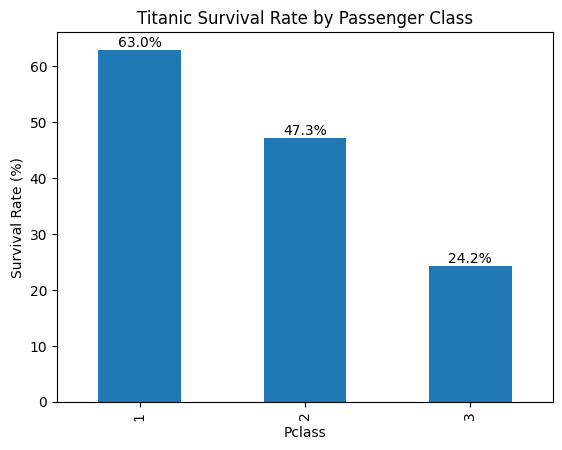

In [43]:
survival_by_class = (
    df.groupby("Pclass")["Survived"]
    .mean() * 100
)

ax = survival_by_class.plot(kind="bar")

plt.title("Titanic Survival Rate by Passenger Class")
plt.ylabel("Survival Rate (%)")
for container in ax.containers: 
    ax.bar_label(container, fmt='%.1f%%')
plt.show()

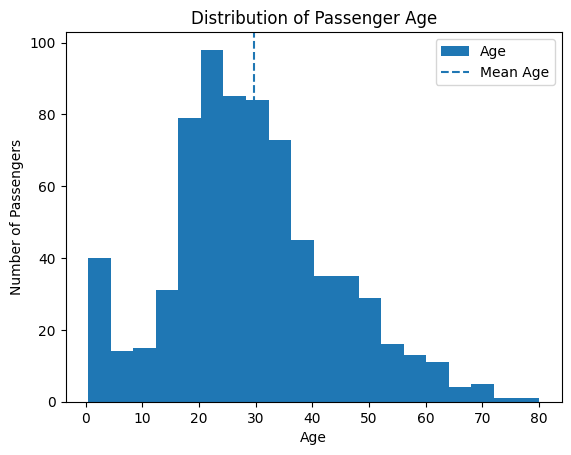

In [44]:
df["Age"].plot(kind="hist", bins=20)

plt.axvline(
    df["Age"].mean(),
    linestyle="--",
    label="Mean Age"
)

plt.title("Distribution of Passenger Age")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.legend()

plt.show()

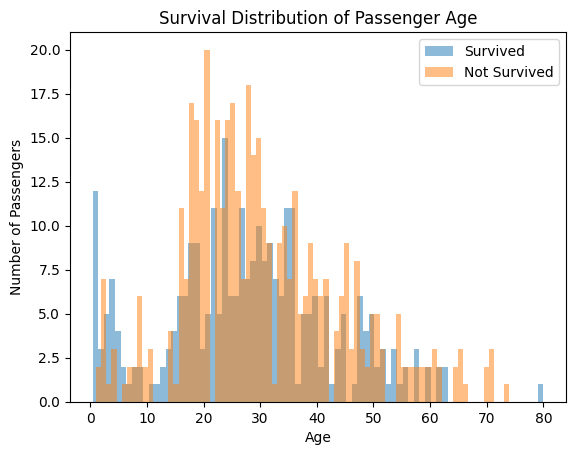

In [45]:
df[df["Survived"] == 1]["Age"].plot(
    kind="hist",
    bins=80,
    alpha=0.5,
    label="Survived"
)

df[df["Survived"] == 0]["Age"].plot(
    kind="hist",
    bins=80,
    alpha=0.5,
    label="Not Survived"
)

plt.title("Survival Distribution of Passenger Age")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.legend()
plt.show()

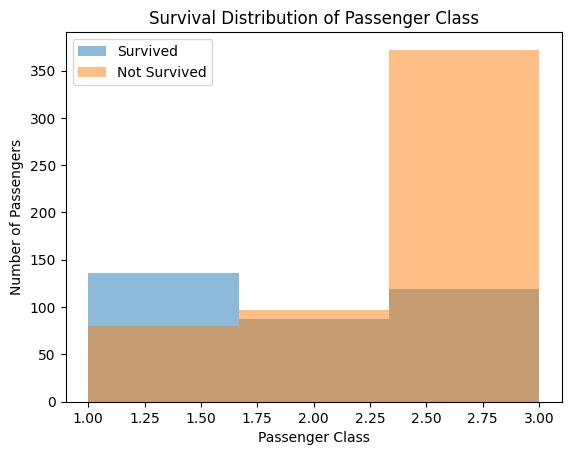

In [46]:
df[df["Survived"] == 1]["Pclass"].plot(
    kind="hist",
    bins=3,
    alpha=0.5,
    label="Survived"
)

df[df["Survived"] == 0]["Pclass"].plot(
    kind="hist",
    bins=3,
    alpha=0.5,
    label="Not Survived"
)

plt.title("Survival Distribution of Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")
plt.legend()
plt.show()

## Missing Value Handling

The dataset contains missing values in Age, Cabin, and Embarked.

- Missing Embarked values were filled using the mode because only two records were missing.
- Missing Age values were filled using the median age to reduce the impact of outliers.
- Cabin contained more than 77% missing values. A binary indicator (Cabin_missing) was created to preserve potential information before dropping the original column.


In [47]:
# Embarked
df["Embarked"] = df["Embarked"].fillna(
    df["Embarked"].mode()[0]
)

# Age
df["Age"] = df["Age"].fillna(
    df["Age"].median()
)

# Cabin indicator
df["Cabin_missing"] = df["Cabin"].isnull()

# Drop cabin
df = df.drop("Cabin", axis=1)